In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("EDA environment is working!")

EDA environment is working!


In [2]:
# Load the Telco Customer Churn dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check column names and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Basic statistical summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Churn distribution

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# Separate numerical and categorical columns

numerical_columns = df.select_dtypes(include=["number"]).columns
categorical_columns = df.select_dtypes(include=["str"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [7]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [8]:
eda_df = df.copy()

print("EDA copy created successfully!")

EDA copy created successfully!


In [9]:
eda_df[['Contract', 'tenure', 'Churn']].head()

,Contract,tenure,Churn
0,Month-to-month,1,No
1,One year,34,No
2,Month-to-month,2,Yes
3,One year,45,No
4,Month-to-month,2,Yes


In [10]:
eda_df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
contract_churn = pd.crosstab(
    eda_df['Contract'],
    eda_df['Churn'],
    normalize='index'
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
contract_rate = (
    eda_df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

contract_rate.round(2)

,Contract,ChurnRate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


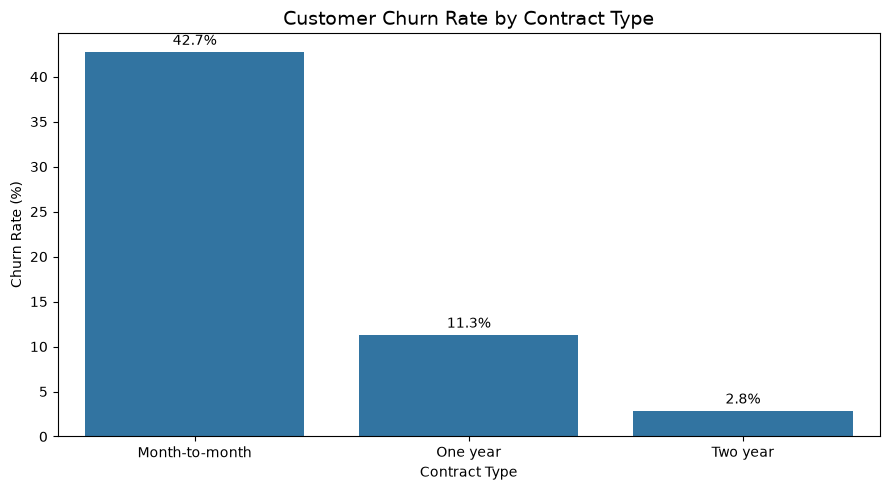

In [15]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_rate,
    x='Contract',
    y='ChurnRate'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.title('Customer Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [16]:
tenure_stats = eda_df.groupby('Churn')['tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

tenure_stats

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


In [17]:
eda_df['TenureGroup'] = pd.cut(
    eda_df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        '0–12 Months',
        '13–24 Months',
        '25–48 Months',
        '49–72 Months'
    ]
)

In [18]:
eda_df['TenureGroup'].value_counts().sort_index()

TenureGroup
0–12 Months     2186
13–24 Months    1024
25–48 Months    1594
49–72 Months    2239
Name: count, dtype: int64

In [21]:
tenure_rate = (
    eda_df.groupby('TenureGroup', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

tenure_rate.round(2)

,TenureGroup,ChurnRate
0,0–12 Months,47.44
1,13–24 Months,28.71
2,25–48 Months,20.39
3,49–72 Months,9.51


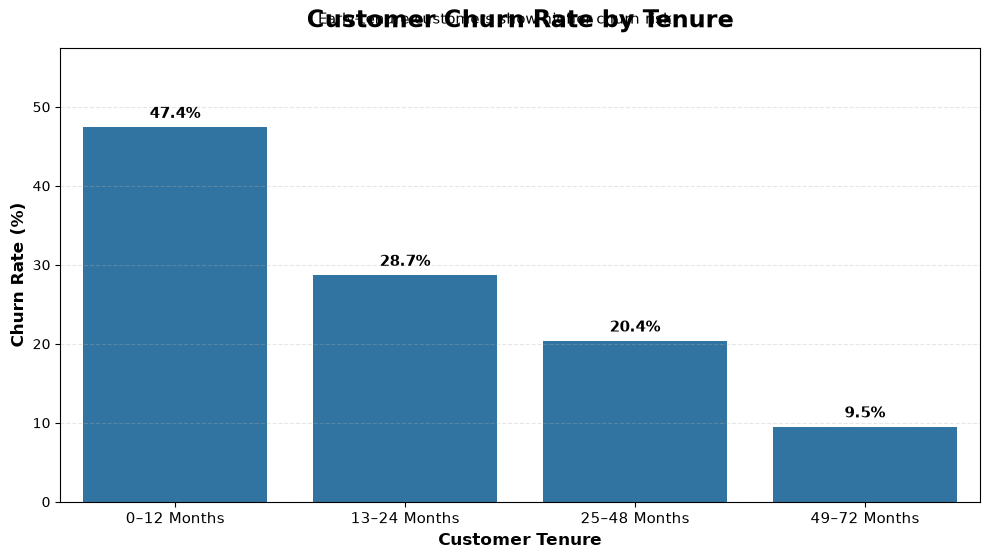

In [23]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=tenure_rate,
    x='TenureGroup',
    y='ChurnRate',
    errorbar=None
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

# Titles and labels
plt.title(
    'Customer Churn Rate by Tenure',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.suptitle(
    'Early-tenure customers show higher churn risk',
    fontsize=11,
    y=0.92
)

plt.xlabel(
    'Customer Tenure',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Churn Rate (%)',
    fontsize=12,
    fontweight='bold'
)

# Improve readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.ylim(
    0,
    tenure_rate['ChurnRate'].max() + 10
)

plt.tight_layout()
plt.show()

In [24]:
contract_tenure = (
    eda_df.groupby(
        ['Contract', 'TenureGroup'],
        observed=True
    )['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

contract_tenure.round(2)

,Contract,TenureGroup,ChurnRate
0,Month-to-month,0–12 Months,51.35
1,Month-to-month,13–24 Months,37.72
2,Month-to-month,25–48 Months,32.92
3,Month-to-month,49–72 Months,26.02
4,One year,0–12 Months,10.48
5,One year,13–24 Months,8.12
6,One year,25–48 Months,10.62
7,One year,49–72 Months,12.93
8,Two year,0–12 Months,0.00
9,Two year,13–24 Months,0.00


In [27]:
heatmap_data = contract_tenure.pivot(
    index='Contract',
    columns='TenureGroup',
    values='ChurnRate'
)

heatmap_data.round(2)

TenureGroup,0–12 Months,13–24 Months,25–48 Months,49–72 Months
Contract,,,,
Month-to-month,51.35,37.72,32.92,26.02
One year,10.48,8.12,10.62,12.93
Two year,0.00,0.00,2.19,3.33


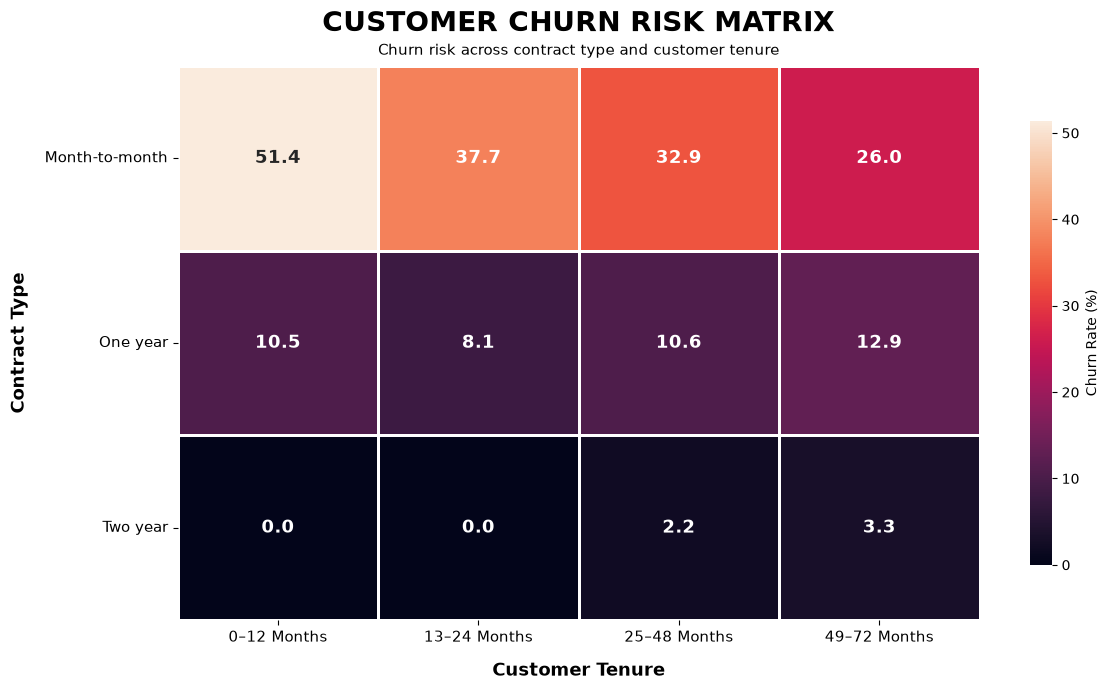

In [28]:
plt.figure(figsize=(12, 7))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    linewidths=2,
    linecolor='white',
    cbar_kws={
        'label': 'Churn Rate (%)',
        'shrink': 0.8
    },
    annot_kws={
        'fontsize': 13,
        'fontweight': 'bold'
    }
)

# Main title
plt.title(
    'CUSTOMER CHURN RISK MATRIX',
    fontsize=20,
    fontweight='bold',
    pad=25
)

# Subtitle
plt.text(
    0.5,
    1.02,
    'Churn risk across contract type and customer tenure',
    transform=ax.transAxes,
    ha='center',
    fontsize=11
)

# Axis labels
plt.xlabel(
    'Customer Tenure',
    fontsize=13,
    fontweight='bold',
    labelpad=12
)

plt.ylabel(
    'Contract Type',
    fontsize=13,
    fontweight='bold',
    labelpad=12
)

# Tick labels
plt.xticks(
    fontsize=11,
    rotation=0
)

plt.yticks(
    fontsize=11,
    rotation=0
)

# Color bar label
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

# Layout
plt.tight_layout()

# Display
plt.show()

In [29]:
highest_risk = contract_tenure.loc[
    contract_tenure['ChurnRate'].idxmax()
]

print(
    f"Highest-risk segment: "
    f"{highest_risk['Contract']} contract + "
    f"{highest_risk['TenureGroup']} tenure"
)

print(
    f"Churn rate: {highest_risk['ChurnRate']:.2f}%"
)

Highest-risk segment: Month-to-month contract + 0–12 Months tenure
Churn rate: 51.35%


 Executive Insight

Highest-Risk Customer Segment

**Month-to-month customers with 0–12 months of tenure show the highest churn rate at 51.35%.**

The analysis indicates that customers with shorter tenure and month-to-month contracts are considerably more vulnerable to churn than customers with longer-term contracts.

### Business Interpretation

The early customer lifecycle appears to be a critical retention period. Customers in this segment may benefit from stronger onboarding, proactive engagement and targeted retention initiatives.

### Key Takeaway

**Contract commitment + customer tenure can be used together to identify high-risk customer segments and support targeted retention strategies.**

In [31]:
print("=" * 55)
print("             CHURN RISK SUMMARY")
print("=" * 55)

print(f"Highest-risk contract : {highest_risk['Contract']}")
print(f"Highest-risk tenure   : {highest_risk['TenureGroup']}")
print(f"Churn rate            : {highest_risk['ChurnRate']:.2f}%")

print("=" * 55)

             CHURN RISK SUMMARY
Highest-risk contract : Month-to-month
Highest-risk tenure   : 0–12 Months
Churn rate            : 51.35%


In [32]:
payment_churn = (
    eda_df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
    .sort_values('ChurnRate', ascending=False)
)

payment_churn.round(2)

,PaymentMethod,ChurnRate
2,Electronic check,45.29
3,Mailed check,19.11
0,Bank transfer (automatic),16.71
1,Credit card (automatic),15.24


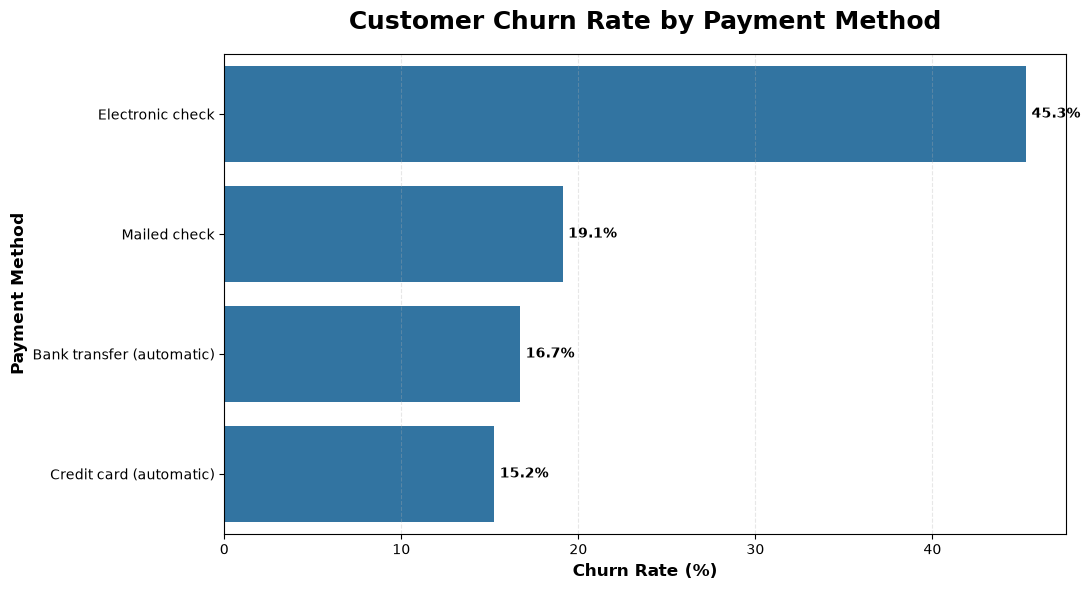

In [33]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=payment_churn,
    x='ChurnRate',
    y='PaymentMethod',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=4,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Payment Method',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Churn Rate (%)',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Payment Method',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [35]:
internet_churn = (
    eda_df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
    .sort_values('ChurnRate', ascending=False)
)

internet_churn.round(2)

,InternetService,ChurnRate
1,Fiber optic,41.89
0,DSL,18.96
2,No,7.40


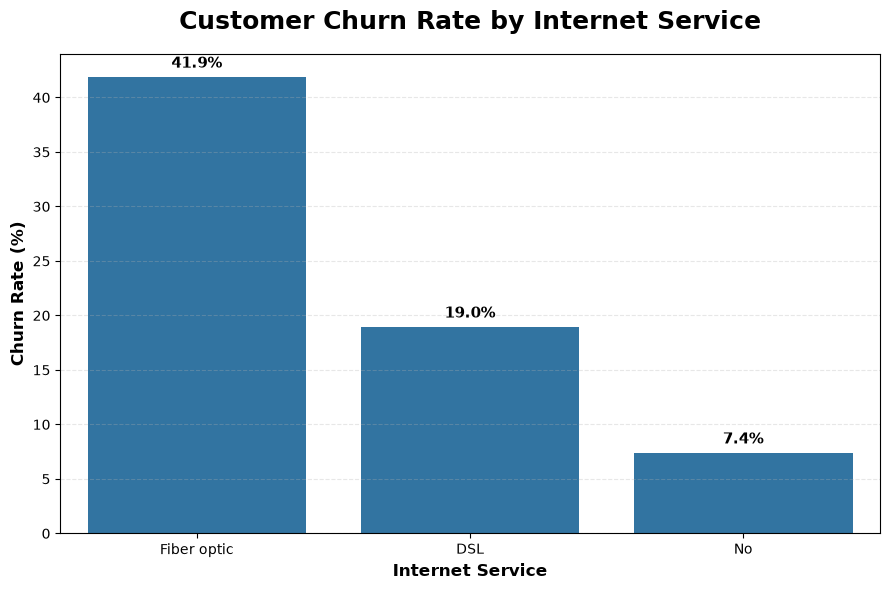

In [36]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=internet_churn,
    x='InternetService',
    y='ChurnRate',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Customer Churn Rate by Internet Service',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Internet Service',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Churn Rate (%)',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

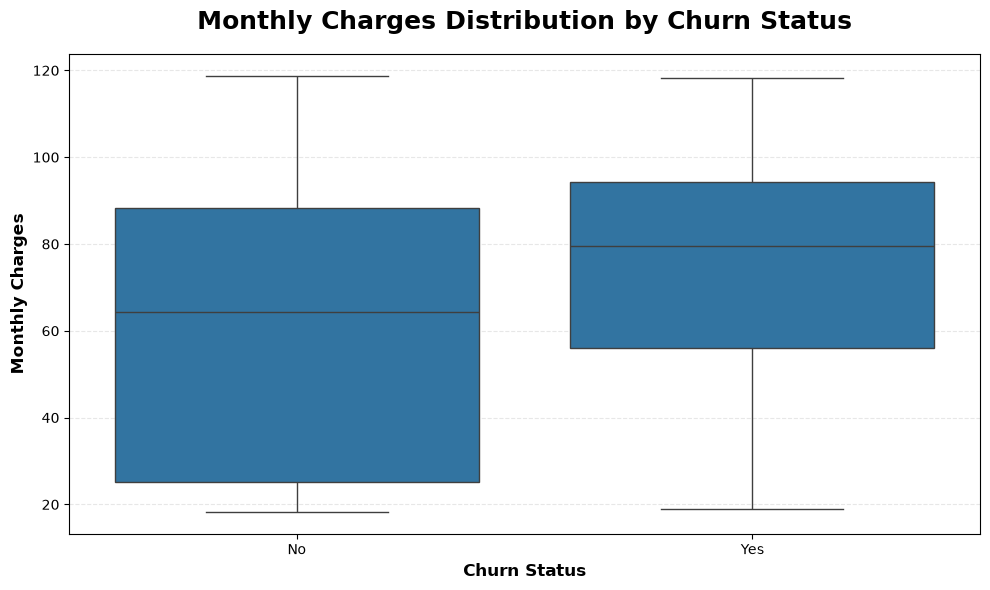

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title(
    'Monthly Charges Distribution by Churn Status',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Churn Status',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Monthly Charges',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 💡 Insight — Monthly Charges

The distribution of monthly charges differs between customers who churned and those who remained. This suggests that pricing level may be an important factor to investigate further during feature engineering and predictive modelling.

In [38]:
service_columns = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

service_results = []

for column in service_columns:
    temp = (
        eda_df.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='ChurnRate')
    )

    temp['Feature'] = column
    service_results.append(temp)

service_churn = pd.concat(
    service_results,
    ignore_index=True
)

service_churn.round(2)

,OnlineSecurity,ChurnRate,Feature,OnlineBackup,DeviceProtection,TechSupport
0,No,41.77,OnlineSecurity,NaN,NaN,NaN
1,No internet service,7.40,OnlineSecurity,NaN,NaN,NaN
2,Yes,14.61,OnlineSecurity,NaN,NaN,NaN
3,NaN,39.93,OnlineBackup,No,NaN,NaN
4,NaN,7.40,OnlineBackup,No internet service,NaN,NaN
5,NaN,21.53,OnlineBackup,Yes,NaN,NaN
6,NaN,39.13,DeviceProtection,NaN,No,NaN
7,NaN,7.40,DeviceProtection,NaN,No internet service,NaN
8,NaN,22.50,DeviceProtection,NaN,Yes,NaN
9,NaN,41.64,TechSupport,NaN,NaN,No


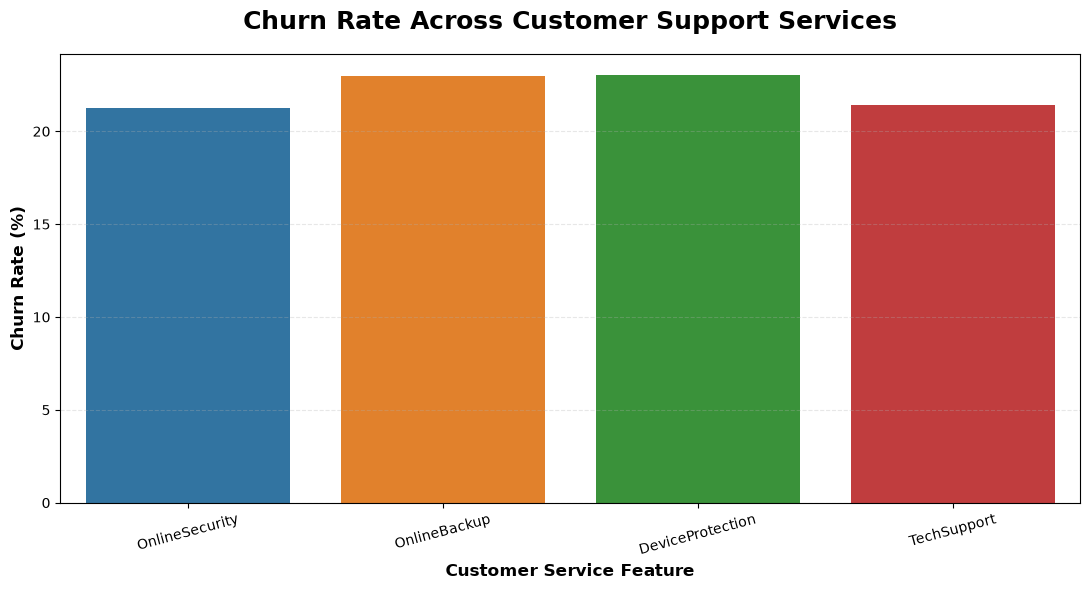

In [39]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=service_churn,
    x='Feature',
    y='ChurnRate',
    hue='Feature',
    errorbar=None,
    legend=False
)

plt.title(
    'Churn Rate Across Customer Support Services',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Customer Service Feature',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Churn Rate (%)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(rotation=15)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

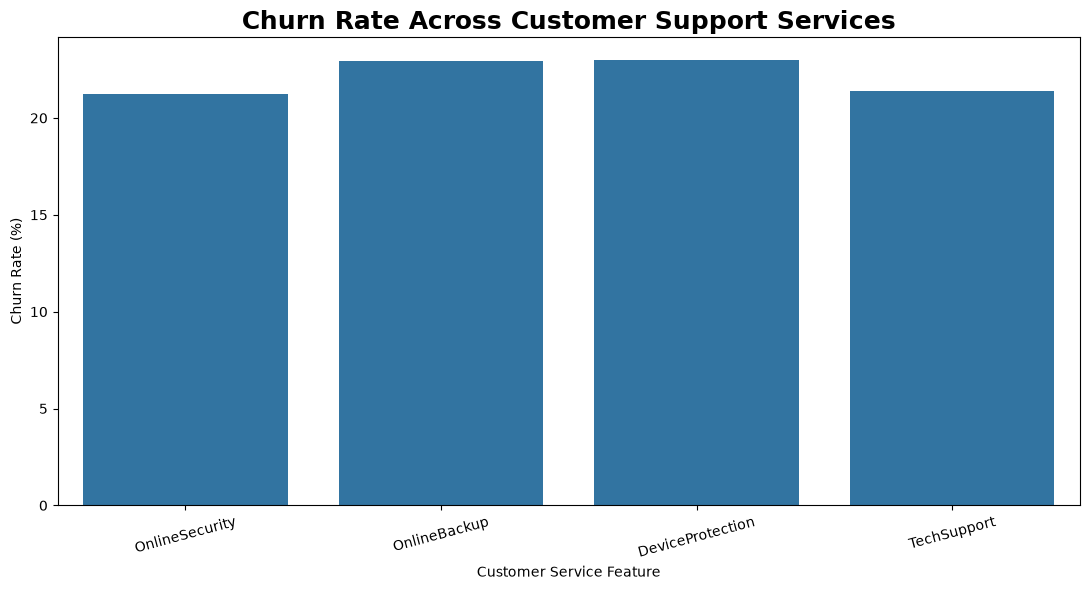

In [40]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=service_churn,
    x='Feature',
    y='ChurnRate',
    errorbar=None
)

plt.title(
    'Churn Rate Across Customer Support Services',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Customer Service Feature')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


In [41]:
service_summary = (
    service_churn
    .groupby('Feature')['ChurnRate']
    .agg(['min', 'max'])
    .reset_index()
)

service_summary['Difference'] = (
    service_summary['max'] - service_summary['min']
)

service_summary = service_summary.sort_values(
    'Difference',
    ascending=False
)

service_summary.round(2)

,Feature,min,max,Difference
2,OnlineSecurity,7.4,41.77,34.36
3,TechSupport,7.4,41.64,34.23
1,OnlineBackup,7.4,39.93,32.52
0,DeviceProtection,7.4,39.13,31.72


In [43]:
top_service = service_summary.iloc[0]

print("Strongest service-related churn difference")
print("-" * 50)
print(f"Service   : {top_service['Feature']}")
print(f"Difference: {top_service['Difference']:.2f}%")
print("-" * 50)

Strongest service-related churn difference
--------------------------------------------------
Service   : OnlineSecurity
Difference: 34.36%
--------------------------------------------------


### 💡 Support Service Insight

The analysis compares churn rates across customers with different support and security services.

The service with the largest observed difference in churn rate was identified using the calculated churn-rate gap.

This suggests that customer support and service features may provide useful signals for identifying customers at higher risk of churn.

In [44]:
driver_features = [
    'Contract',
    'InternetService',
    'PaymentMethod',
    'TechSupport',
    'OnlineSecurity'
]

driver_results = []

for feature in driver_features:
    temp = (
        eda_df.groupby(feature)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='ChurnRate')
    )

    temp['Feature'] = feature
    temp['Category'] = temp[feature].astype(str)

    driver_results.append(
        temp[['Feature', 'Category', 'ChurnRate']]
    )

churn_drivers = pd.concat(
    driver_results,
    ignore_index=True
)

churn_drivers = churn_drivers.sort_values(
    'ChurnRate',
    ascending=False
)

churn_drivers.head(15).round(2)

,Feature,Category,ChurnRate
8,PaymentMethod,Electronic check,45.29
0,Contract,Month-to-month,42.71
4,InternetService,Fiber optic,41.89
13,OnlineSecurity,No,41.77
10,TechSupport,No,41.64
9,PaymentMethod,Mailed check,19.11
3,InternetService,DSL,18.96
6,PaymentMethod,Bank transfer (automatic),16.71
7,PaymentMethod,Credit card (automatic),15.24
12,TechSupport,Yes,15.17


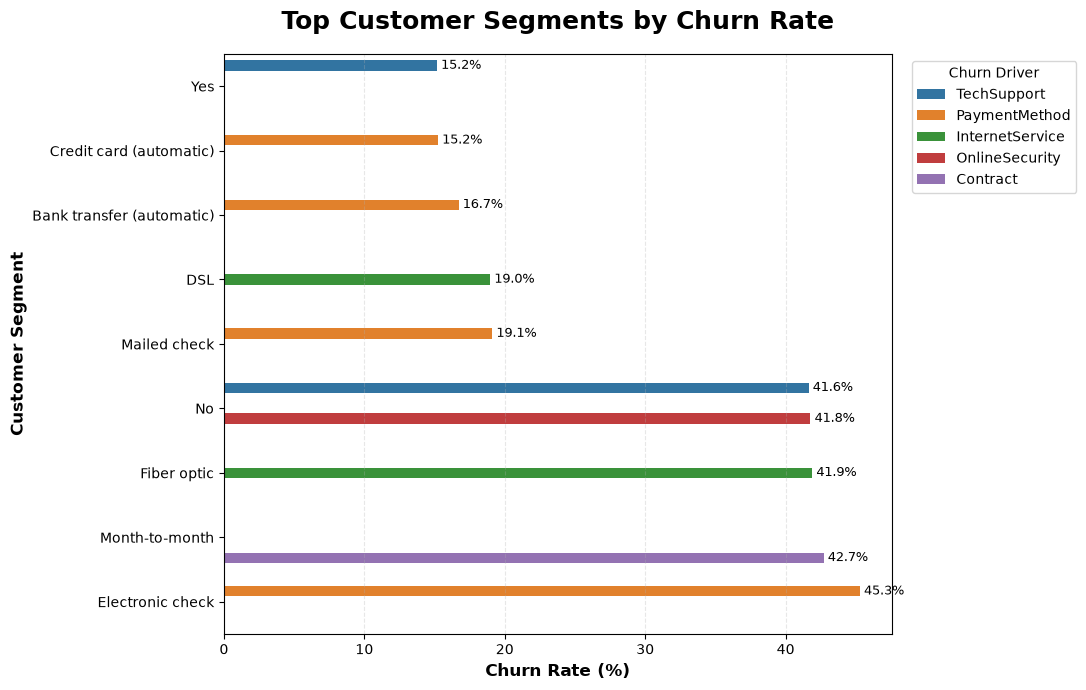

In [45]:
top_drivers = churn_drivers.head(10).sort_values(
    'ChurnRate',
    ascending=True
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top_drivers,
    x='ChurnRate',
    y='Category',
    hue='Feature',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

plt.title(
    'Top Customer Segments by Churn Rate',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Churn Rate (%)',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Customer Segment',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='Churn Driver',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [46]:
top_segment = churn_drivers.iloc[0]

print("=" * 60)
print("              TOP CHURN-RISK SEGMENT")
print("=" * 60)

print(f"Feature  : {top_segment['Feature']}")
print(f"Category : {top_segment['Category']}")
print(f"Churn    : {top_segment['ChurnRate']:.2f}%")

print("=" * 60)

              TOP CHURN-RISK SEGMENT
Feature  : PaymentMethod
Category : Electronic check
Churn    : 45.29%


# 📊 DAY 5 — FINAL EDA SUMMARY

## 🔍 Analysis Completed

The final stage of EDA examined additional customer characteristics associated with churn, including:

- 💳 Payment Method
- 🌐 Internet Service
- 💰 Monthly Charges
- 🛠️ Technical Support
- 🔐 Online Security
- 📊 Major categorical churn segments

## 🎯 Key Findings

The analysis revealed differences in churn behaviour across several customer segments.

The results from Day 4 showed that **Month-to-month customers with 0–12 months of tenure had the highest observed churn rate of 51.35%**.

Additional Day 5 analysis identified further customer characteristics that can be used as potential predictors in the upcoming machine-learning stage.

## 💡 Business Perspective

The EDA suggests that churn is not associated with a single customer characteristic. Contract commitment, tenure, service configuration, payment method and pricing-related factors should be considered together when developing a churn prediction model.

## 🚀 Next Stage

The cleaned and explored dataset is now ready for:

**Feature Engineering → Model Training → Model Evaluation → Churn Prediction**